# Word Embeddings with CBOW & Skip-gram (In Search of the Castaways)

This notebook trains **CBOW and Skip-gram Word2Vec models** using the novel **In Search of the Castaways**. It includes cosine similarity examples and PCA visualization.

In [1]:
!pip install gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.1 MB/s eta 0:00:00


In [2]:
import nltk
import re
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Load and preprocess dataset

In [4]:
nltk.download('punkt_tab')

# Load text file (upload 'In Search of the Castaways dataset.txt' to Colab)
with open('/content/test.csv', encoding='utf-8') as f:
    text = f.read().lower()

# Clean text
text = re.sub(r'[^a-z\s]', ' ', text)
text = re.sub(r'\s+', ' ', text)

# Tokenize into words
words = nltk.word_tokenize(text)

# Create pseudo-sentences (Word2Vec needs list of lists)
sentences = []
sentence = []
for w in words:
    sentence.append(w)
    if len(sentence) >= 10:
        sentences.append(sentence)
        sentence = []

print('Total sentences:', len(sentences))
print('Sample sentence:', sentences[0][:10])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total sentences: 29004
Sample sentence: ['class', 'index', 'title', 'description', 'fears', 'for', 't', 'n', 'pension', 'after']


## Train CBOW model

In [5]:
VECTOR_DIM = 50
WINDOW_SIZE = 2
EPOCHS = 10

cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_DIM,
    window=WINDOW_SIZE,
    min_count=5,
    sg=0,  # CBOW
    epochs=EPOCHS,
    workers=4
)

print('CBOW vocabulary size:', len(cbow_model.wv))

CBOW vocabulary size: 6421


## Train Skip-gram model

In [6]:
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_DIM,
    window=WINDOW_SIZE,
    min_count=5,
    sg=1,  # Skip-gram
    epochs=EPOCHS,
    workers=4
)

print('Skip-gram vocabulary size:', len(skipgram_model.wv))

Skip-gram vocabulary size: 6421


## Cosine Similarity Examples (Novel-related words)

In [7]:
def similarity(model, w1, w2):
    if w1 in model.wv and w2 in model.wv:
        return cosine_similarity(
            model.wv[w1].reshape(1, -1),
            model.wv[w2].reshape(1, -1)
        )[0][0]
    return None

print('Cosine Similarity Examples (Skip-gram):\n')
print('sea vs ship:', similarity(skipgram_model, 'sea', 'ship'))
print('land vs island:', similarity(skipgram_model, 'land', 'island'))
print('captain vs crew:', similarity(skipgram_model, 'captain', 'crew'))
print('journey vs travel:', similarity(skipgram_model, 'journey', 'travel'))
print('sea vs land:', similarity(skipgram_model, 'sea', 'land'))

Cosine Similarity Examples (Skip-gram):

sea vs ship: 0.74300987
land vs island: 0.75283945
captain vs crew: 0.5739242
journey vs travel: None
sea vs land: 0.7629306


## PCA Visualization of Word Embeddings

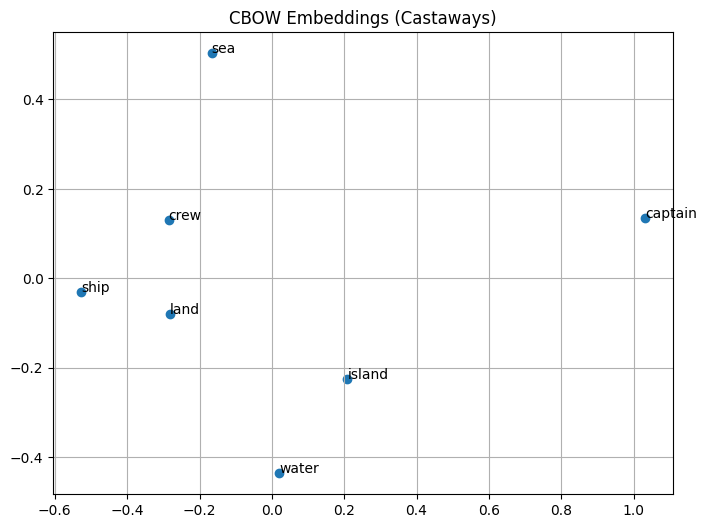

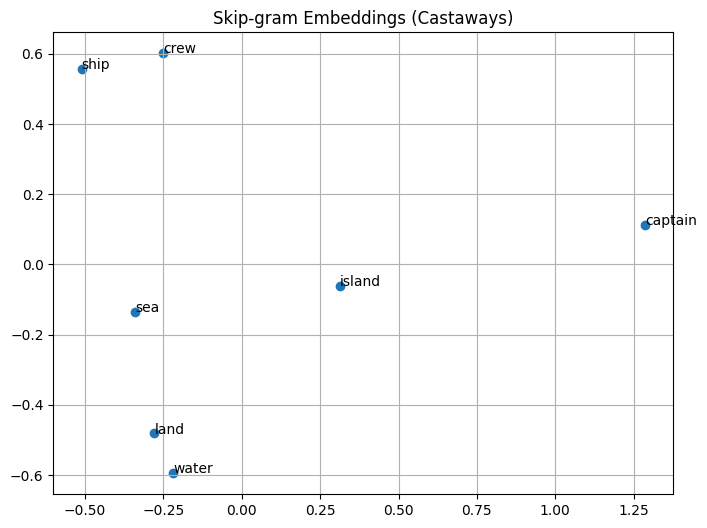

In [8]:
def plot_words(model, words, title):
    vectors = []
    labels = []
    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
            labels.append(w)

    pca = PCA(n_components=2)
    points = pca.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    plt.scatter(points[:, 0], points[:, 1])
    for i, w in enumerate(labels):
        plt.annotate(w, (points[i, 0], points[i, 1]))
    plt.title(title)
    plt.grid(True)
    plt.show()

novel_words = ['sea', 'ship', 'island', 'land', 'journey',
               'captain', 'crew', 'boat', 'water', 'adventure']

plot_words(cbow_model, novel_words, 'CBOW Embeddings (Castaways)')
plot_words(skipgram_model, novel_words, 'Skip-gram Embeddings (Castaways)')